In [1]:
!date

Thu Sep 17 15:33:29 PDT 2026


In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
figdir = f'{projdir}/figures/pmds'
outdir = f'{projdir}/results/qc/data'
!mkdir -p {figdir}

### PMD detection: HMM caller vs a threshold-free definition, all donors genome-wide
Replaces the chr20/3-donor pilots (windowed-threshold notebook and the chr20 HMM comparison).
HMM = dnmtools pmd on each haplotype's own methcounts. Threshold-free = 10kb bins below the
donor's own median mCG by >0.10 (B01b), which needs no caller.

In [4]:
z = np.load(f'{projdir}/results/meth_bins/donor_bin_meth_10kb.npz', allow_pickle=True)
meth, pmd, donors = z['meth'], z['pmd'], list(z['donors'])
print(meth.shape, len(donors), 'donors')

(201, 265052) 201 donors


In [5]:
never_med = np.nanmedian(meth, axis=1, keepdims=True)
low_rel = meth < (never_med - 0.10)
hmm = pmd >= 0.5
both = np.nansum(hmm & low_rel, axis=1); either = np.nansum(hmm | low_rel, axis=1)
d = pd.DataFrame({'sample': donors, 'hmm_bins': np.nansum(hmm, axis=1), 'rel_bins': np.nansum(low_rel, axis=1),
                  'jaccard_hmm_vs_rel': both / either})
dm = pd.read_csv(f'{outdir}/qc13/donor_pmd_expansion_metrics.tsv', sep='\t')[
    ['sample', 'chemistry', 'superpopulation', 'depth_constitutive', 'global_meth']]
d = d.merge(dm, on='sample', how='left')

In [6]:
d.head()

,sample,hmm_bins,rel_bins,jaccard_hmm_vs_rel,chemistry,superpopulation,depth_constitutive,global_meth
0,HG00097,131107,60054,0.317307,R1041,EUR,0.245584,0.520791
1,HG00099,113117,56082,0.301261,R941,EUR,0.197980,0.518563
2,HG00126,117031,52663,0.262444,R1041,EUR,0.188286,0.529499
3,HG00128,134898,60162,0.313509,R1041,EUR,0.236361,0.522023
4,HG00133,118456,55769,0.287028,R1041,EUR,0.201178,0.528512


In [7]:
d.shape

(201, 8)

In [8]:
print(d[['hmm_bins', 'rel_bins', 'jaccard_hmm_vs_rel']].describe().round(3).to_string())
print('\ncorr(HMM bins, threshold-free bins) = %.3f' % d[['hmm_bins', 'rel_bins']].corr().iloc[0, 1])
print('agreement (Jaccard) vs domain depth: r = %.3f' % d[['jaccard_hmm_vs_rel', 'depth_constitutive']].corr().iloc[0, 1])

         hmm_bins   rel_bins  jaccard_hmm_vs_rel
count     201.000    201.000             201.000
mean   128942.721  54689.448               0.284
std     10453.585   6531.889               0.048
min    100658.000  40180.000               0.172
25%    121613.000  49634.000               0.247
50%    129093.000  54433.000               0.283
75%    135953.000  58827.000               0.315
max    165501.000  74916.000               0.433

corr(HMM bins, threshold-free bins) = 0.704
agreement (Jaccard) vs domain depth: r = 0.947


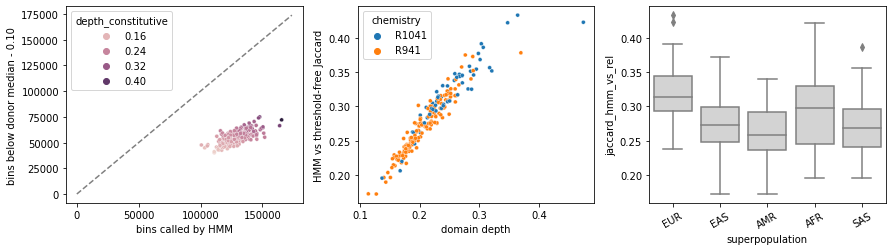

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
sns.scatterplot(data=d, x='hmm_bins', y='rel_bins', hue='depth_constitutive', s=16, ax=axes[0])
lim = [0, d[['hmm_bins', 'rel_bins']].max().max() * 1.05]; axes[0].plot(lim, lim, ls='--', c='grey')
axes[0].set_xlabel('bins called by HMM'); axes[0].set_ylabel('bins below donor median - 0.10')
sns.scatterplot(data=d, x='depth_constitutive', y='jaccard_hmm_vs_rel', hue='chemistry', s=16, ax=axes[1])
axes[1].set_xlabel('domain depth'); axes[1].set_ylabel('HMM vs threshold-free Jaccard')
sns.boxplot(data=d, x='superpopulation', y='jaccard_hmm_vs_rel', ax=axes[2], color='lightgray')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(f'{figdir}/01b_caller_comparison.png', dpi=150)

In [10]:
d.to_csv(f'{outdir}/pmd_caller_comparison_all_donors.tsv', sep='\t', index=False)

In [11]:
!date

Thu Sep 17 15:33:37 PDT 2026
